# Day 2 · 02 SIMPLE — Make the model smaller

Our model works (about 90 % correct), but it is **9 MB** and made of **2.2 million numbers**.
On a phone or a cheap server we want it **smaller and faster** — without making it much worse.

We try two tricks:

| Trick | Everyday idea | What we do to the model |
|---|---|---|
| **Quantization** | round prices: ₹49.97 → ₹50 | store every number with **1 byte** instead of 4 |
| **Pruning** | throw away things you never use | set the **smallest** numbers to 0 |

After every trick we check the same 3 things:

* 📦 **size** — how big is the file? (smaller is better)
* ⚡ **speed** — how long does 1 picture take? (smaller is better)
* 🎯 **accuracy** — how many test pictures are right? (higher is better)

⏱️ Runs in about 4 minutes. Needs `../models/mobilenetv2_cifar10_fp32.pth` (made in Notebook 01).
The detailed version of this notebook is `02_quantization_and_pruning.ipynb`.

## Step 0 — Setup

Run this cell and move on. It loads the libraries and the pictures, and defines one helper,
**`measure(model)`**, that gives us 📦 size, ⚡ speed and 🎯 accuracy. You don't need to read it.

In [1]:
import copy, os, tempfile, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.ao.quantization as tq
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2
from torchvision.models.quantization import mobilenet_v2 as quantizable_mobilenet_v2

warnings.filterwarnings("ignore")                  # hide technical warnings (explained in the full notebook)
torch.manual_seed(0)

DATA_DIR, MODELS_DIR = Path("..") / "data", Path("..") / "models"
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
prep = transforms.Compose([transforms.Resize((96, 96)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

# PyTorch needs a "quantization engine" (the code that does INT8 maths). Pick the one this computer has.
torch.backends.quantized.engine = next(e for e in ["x86", "fbgemm", "onednn", "qnnpack"]
                                        if e in torch.backends.quantized.supported_engines)

def some(dataset, n, seed):                        # the same random n pictures every time
    idx = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(seed))[:n]
    return Subset(dataset, idx.tolist())

test_pictures  = some(datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=prep), 1000, 42)
train_pictures = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=prep)
test_loader = DataLoader(test_pictures, batch_size=200)

def load_original():
    m = mobilenet_v2(weights=None)
    m.classifier[1] = nn.Linear(1280, 10)
    m.load_state_dict(torch.load(MODELS_DIR / "mobilenetv2_cifar10_fp32.pth", map_location="cpu", weights_only=True))
    return m.eval()

@torch.inference_mode()
def measure(model, name):
    """Return 📦 size (MB), ⚡ time for 1 picture (ms) and 🎯 accuracy (%)."""
    model.eval()
    f = tempfile.NamedTemporaryFile(suffix=".pt", delete=False); f.close()
    torch.save(model.state_dict(), f.name); size = os.path.getsize(f.name) / 1e6; os.remove(f.name)
    torch.set_num_threads(4)
    x = torch.randn(1, 3, 96, 96)
    for _ in range(10): model(x)                   # warm up
    times = []
    for _ in range(50):
        t = time.perf_counter(); model(x); times.append((time.perf_counter() - t) * 1000)
    right = sum((model(x).argmax(1) == y).sum().item() for x, y in test_loader)
    row = {"model": name, "size_MB": round(size, 2), "time_ms": round(float(np.median(times)), 1),
           "accuracy_%": round(100 * right / len(test_pictures), 1)}
    print(f"{name:32s} 📦 {row['size_MB']:5.2f} MB   ⚡ {row['time_ms']:5.1f} ms   🎯 {row['accuracy_%']:5.1f} %")
    return row

results = []
print("ready ✔  | test pictures:", len(test_pictures), "| engine:", torch.backends.quantized.engine)

ready ✔  | test pictures: 1000 | engine: onednn


## Step 1 — Our starting point

Load the model from Notebook 01 and measure it. Every number inside it is a **float32**: 4 bytes each.

In [2]:
original = load_original()
n_numbers = sum(p.numel() for p in original.parameters())
print(f"the model has {n_numbers:,} numbers × 4 bytes = {n_numbers * 4 / 1e6:.1f} MB\n")
results.append(measure(original, "Original (float32)"))

the model has 2,236,682 numbers × 4 bytes = 8.9 MB

Original (float32)               📦  9.19 MB   ⚡  39.6 ms   🎯  88.8 %


👀 **Remember these three numbers** — every trick below is compared with them.

---

## Step 2 — What is quantization? (with 8 numbers)

Take 8 weights from the model. Quantization does 3 things:

1. find the biggest number (ignoring the sign) → it becomes **127**, the biggest value 1 byte can hold
2. **scale** = biggest ÷ 127 — the size of one "step"
3. every number → `round(number ÷ scale)` → a whole number between −127 and 127 (**1 byte!**)

To use it again, multiply back: `whole number × scale`.

In [3]:
w = original.classifier[1].weight[0, :8].detach()      # 8 real weights from the last layer

scale = w.abs().max() / 127                            # size of one step
as_int8 = torch.round(w / scale)                       # stored: whole numbers, 1 byte each
back = as_int8 * scale                                 # used: back to decimals

print(f"scale = {scale:.6f}\n")
display(pd.DataFrame({"original (4 bytes)": w.numpy().round(5),
                      "stored as int8 (1 byte)": as_int8.int().numpy(),
                      "back to decimal": back.numpy().round(5),
                      "error": (w - back).abs().numpy().round(6)}))
print(f"biggest error: {(w - back).abs().max():.6f}  (always ≤ half a step = {scale / 2:.6f})")

scale = 0.000223



,original (4 bytes),stored as int8 (1 byte),back to decimal,error
0,-0.00187,-8,-0.00178,0.000086
1,0.00716,32,0.00712,0.000036
2,0.00748,34,0.00757,0.000085
3,0.02328,105,0.02338,0.000097
4,-0.02828,-127,-0.02828,0.000000
5,0.01181,53,0.01180,0.000011
6,-0.01297,-58,-0.01291,0.000055
7,-0.01779,-80,-0.01781,0.000017


biggest error: 0.000097  (always ≤ half a step = 0.000111)


👀 **What to notice**

* The stored numbers are small **whole numbers** → 1 byte instead of 4 → **4× smaller**.
* The numbers we get back are **almost** the original — the error is tiny (at most half a step).
* It's like rounding prices: you lose the paise, but the total is still about right.

---

## Step 3 — Quantize the whole model (3 small steps)

PyTorch does the same rounding for all 2.2 million numbers. The only extra idea:
the numbers **flowing between layers** (not just the weights) must be rounded too, and for those PyTorch must
first *see* how big they get. So we **show it a few pictures** — that's called **calibration**.

| Step | What happens | Everyday idea |
|---|---|---|
| **3a prepare** | copy the model into a "quantization-ready" version and attach small *recorders* | put a ruler on every pipe |
| **3b calibrate** | send 200 training pictures through; recorders note the min/max of each layer | measure the water flow |
| **3c convert** | replace every float layer by an **int8** layer using those ranges | swap pipes for smaller ones that fit |

In [4]:
# 3a — prepare
q_model = quantizable_mobilenet_v2(weights=None, quantize=False)   # same model, but "quantization-ready"
q_model.classifier[1] = nn.Linear(1280, 10)
q_model.load_state_dict(original.state_dict())                     # our trained weights
q_model.eval()
q_model.fuse_model()                                               # glue Conv+BatchNorm+ReLU into one layer
q_model.qconfig = tq.get_default_qconfig(torch.backends.quantized.engine)   # "use int8, the standard way"
tq.prepare(q_model, inplace=True)                                  # attach the recorders

# 3b — calibrate: show 200 TRAINING pictures (never the test pictures!)
with torch.inference_mode():
    for x, _ in DataLoader(some(train_pictures, 200, 1), batch_size=50):
        q_model(x)

# 3c — convert to int8
tq.convert(q_model, inplace=True)
print("done ✔ — a layer now looks like this:\n", q_model.features[1].conv[1], "\n")

results.append(measure(q_model, "Quantized (int8)"))

done ✔ — a layer now looks like this:
 QuantizedConv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), scale=0.03601139411330223, zero_point=123) 

Quantized (int8)                 📦  2.66 MB   ⚡  14.0 ms   🎯  81.6 %


👀 **What to notice** — compare with Step 1:

* 📦 about **3.5× smaller** (not exactly 4×: each layer also stores its *scale*).
* 🎯 accuracy almost the same — usually less than 1 point lower.
* ⚡ a bit faster on most computers (int8 maths is cheaper).

**This is the main result of the day:** a much smaller model for almost free.

---

## Step 4 — Pruning: delete the smallest numbers

Many weights are close to 0 and barely matter. Pruning sets the **smallest X %** of them to exactly 0.
Let's try 30 % and 50 %.

In [5]:
def prune_smallest(model, fraction):
    """Set the smallest `fraction` of all weights (whole model) to 0."""
    m = copy.deepcopy(model)
    layers = [(layer, "weight") for layer in m.modules() if isinstance(layer, (nn.Conv2d, nn.Linear))]
    prune.global_unstructured(layers, pruning_method=prune.L1Unstructured, amount=fraction)
    return m

def zeros_percent(model):
    ws = [layer.weight for layer in model.modules() if isinstance(layer, (nn.Conv2d, nn.Linear))]
    return 100 * sum(int((w == 0).sum()) for w in ws) / sum(w.numel() for w in ws)

pruned = {}
for fraction in [0.3, 0.5]:
    m = prune_smallest(original, fraction)
    for layer in m.modules():                                  # make the zeros permanent
        if isinstance(layer, (nn.Conv2d, nn.Linear)):
            prune.remove(layer, "weight")
    pruned[fraction] = m
    print(f"{zeros_percent(m):.0f} % of the weights are now 0")
    results.append(measure(m, f"Pruned {int(fraction * 100)} %"))

30 % of the weights are now 0
Pruned 30 %                      📦  9.19 MB   ⚡  15.9 ms   🎯  86.5 %
50 % of the weights are now 0
Pruned 50 %                      📦  9.19 MB   ⚡  15.5 ms   🎯  32.2 %


👀 **What to notice**

* 🎯 **30 %** deleted → accuracy drops a little. **50 %** deleted → the model **breaks** (accuracy collapses).
* 📦 **size did not change!** A 0 is still stored as a full 4-byte number. Pruning only shrinks the file
  after zipping it, or with special formats (Step 6 shows why, and how to fix it).
* ⚡ speed did not change either (small ups and downs are just measurement noise): the computer multiplies
  by 0 just as fast as by any other number.

### Can we repair the 50 % model?

Yes — **practice again**. Like a football team that lost half its players: the rest must train together
before they play well again. We keep the zeros **locked at 0** and let the other weights re-learn
for one short round (1 000 training pictures, a few seconds).

In [6]:
train_aug = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=transforms.Compose([
    transforms.Resize((96, 96)), transforms.RandomHorizontalFlip(), transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)]))

repaired = prune_smallest(original, 0.5)          # zeros are LOCKED (a mask keeps them at 0 while training)
optimizer = torch.optim.AdamW(repaired.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()
repaired.train()
for x, y in DataLoader(some(train_aug, 1000, 2), batch_size=32, shuffle=True):
    loss = loss_fn(repaired(x), y)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
for layer in repaired.modules():
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        prune.remove(layer, "weight")

print(f"still {zeros_percent(repaired):.0f} % zeros")
results.append(measure(repaired, "Pruned 50 % + re-trained"))

still 50 % zeros
Pruned 50 % + re-trained         📦  9.19 MB   ⚡  24.0 ms   🎯  84.8 %


👀 **What to notice:** one short practice round brings the 50 % model from ~30 % back to ~85 % accuracy —
with half of its weights still 0. More practice would bring it even closer to the original. Real projects repeat: prune a bit → re-train → prune a bit more.

---

## Step 5 — Compare everything

,size_MB,time_ms,accuracy_%
model,,,
Original (float32),9.19,39.6,88.8
Quantized (int8),2.66,14.0,81.6
Pruned 30 %,9.19,15.9,86.5
Pruned 50 %,9.19,15.5,32.2
Pruned 50 % + re-trained,9.19,24.0,84.8


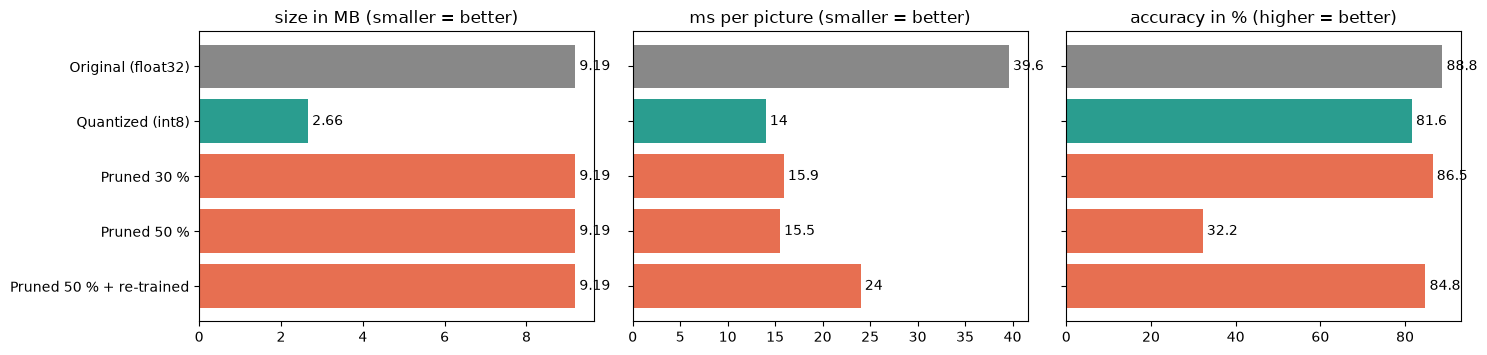

In [7]:
def compare(results):
    """Table + 3 bar charts: 📦 size, ⚡ time, 🎯 accuracy for every model measured so far."""
    table = pd.DataFrame(results).set_index("model")
    display(table)
    colour = lambda name: ("#888" if name.startswith("Original") else "#2a9d8f" if name.startswith("Quantized")
                           else "#7b2cbf" if name.startswith("Channels") else "#e76f51")
    fig, axes = plt.subplots(1, 3, figsize=(15, 0.9 + 0.55 * len(table)))
    for ax, col, title in zip(axes, ["size_MB", "time_ms", "accuracy_%"],
                              ["size in MB (smaller = better)", "ms per picture (smaller = better)",
                               "accuracy in % (higher = better)"]):
        bars = ax.barh(table.index, table[col], color=[colour(n) for n in table.index])
        ax.bar_label(bars, padding=3); ax.set_title(title); ax.invert_yaxis()
    for ax in axes[1:]:
        ax.set_yticklabels([])
    plt.tight_layout(); plt.show()

compare(results)

👀 Grey = original, green = quantized, orange = pruned.

Look at the **orange size bars**: exactly as long as the grey one. We set half of the numbers to 0 and saved **nothing**,
and the time didn't improve either. Step 6 finds out why, and fixes it.

---

## Step 6 — Why didn't pruning shrink anything? 🔍

Every layer is a **table of numbers**. Step 4 wrote **0** into many cells, but the table is still the same size:

```
 original table          Step 4: smallest → 0        Step 6: delete the weak ROW
 0.30  -0.10   0.70       0.30   0      0.70          0.30  -0.10   0.70
 0.02   0.01  -0.03       0      0      0             (row deleted)
-0.50   0.20   0.10      -0.50   0.20   0            -0.50   0.20   0.10

 9 numbers stored         still 9 numbers stored       6 numbers stored
 9 multiplications        still 9 (× 0 is not skipped) 6 multiplications
```

* 📦 A **0 is still a number**: it still takes 4 bytes in the file.
* ⚡ The computer multiplies **whole tables at once** and never checks for zeros. × 0 takes as long as × 0.37.
* ✅ Only when whole **rows** disappear (called **structured pruning**) does the table really get smaller.

Let's check both facts, then really delete rows.

### Structured pruning: delete whole channels of MobileNetV2

MobileNetV2 is made of 17 small **blocks**. Each block *widens* the picture into many **inner channels**
(e.g. 24 → 144), works on them, then *narrows* back. We keep only the **strongest half of the inner channels**
in every block, so three layers per block really get smaller (fewer rows *and* fewer columns).

* **Which channels are weak?** Every channel has a BatchNorm "volume knob". A channel whose knob is turned almost to 0
  barely adds anything to the answer, so it goes first.
* We don't touch the outside of a block: its shortcut adds input + output (`x + block(x)`), so both must stay the same size.

In [11]:
def remove_channels(model, fraction):
    """Delete the weakest `fraction` of the inner channels in every MobileNetV2 block (structured pruning)."""
    m = copy.deepcopy(model)
    for block in m.features:
        if not hasattr(block, "conv") or len(block.conv) != 4:        # the first block has no inner channels to remove
            continue
        widen, work, narrow = block.conv[0], block.conv[1], block.conv[2]
        n = widen[0].out_channels
        strength = widen[1].weight.abs()                              # the BatchNorm "volume knob" of each channel
        keep = strength.argsort(descending=True)[: int(n * (1 - fraction))].sort().values

        def smaller_conv(old, weights, groups=1):
            new = nn.Conv2d(weights.shape[1] * groups, weights.shape[0], old.kernel_size, old.stride,
                            old.padding, groups=groups, bias=False)
            new.weight.data = weights.clone()
            return new

        def smaller_bn(old):
            new = nn.BatchNorm2d(len(keep))
            for name in ["weight", "bias", "running_mean", "running_var"]:
                getattr(new, name).data = getattr(old, name).data[keep].clone()
            return new

        widen[0] = smaller_conv(widen[0], widen[0].weight.data[keep])                 # fewer output rows
        widen[1] = smaller_bn(widen[1])
        work[0] = smaller_conv(work[0], work[0].weight.data[keep], groups=len(keep))  # fewer channels
        work[1] = smaller_bn(work[1])
        block.conv[2] = smaller_conv(narrow, narrow.weight.data[:, keep])             # fewer input columns
    return m.eval()

slim = remove_channels(original, 0.5)
n_slim = sum(p.numel() for p in slim.parameters())
print(f"numbers in the model: {n_numbers:,} → {n_slim:,}  ({100 * (1 - n_slim / n_numbers):.0f} % really deleted)\n")
results.append(measure(slim, "Channels removed 50 %"))

numbers in the model: 2,236,682 → 1,333,226  (40 % really deleted)

Channels removed 50 %            📦  5.52 MB   ⚡  13.3 ms   🎯   8.7 %


👀 **What to notice:** 📦 the file really shrank, because 40 % of the numbers are really gone (not just set to 0).
⚡ For 1 picture the time barely moves; the 32-picture test below shows the real speed-up.
🎯 But accuracy dropped a lot: whole channels are a bigger loss than single small weights.

Same cure as in Step 4: **practice again**. This time nothing needs to be locked at 0: the deleted channels simply don't exist any more.
The damage is bigger, so we practise longer: 5 000 training pictures (about 1–2 minutes).

In [12]:
optimizer = torch.optim.AdamW(slim.parameters(), lr=3e-4)
slim.train()
for x, y in DataLoader(some(train_aug, 5000, 2), batch_size=32, shuffle=True):
    loss = loss_fn(slim(x), y)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
slim.eval()
results.append(measure(slim, "Channels removed 50 % + re-trained"))

Channels removed 50 % + re-trained 📦  5.52 MB   ⚡  22.4 ms   🎯  74.5 %


👀 **What to notice:** practice brings a lot of accuracy back, but not all of it. Removing whole channels takes away more than
setting tiny weights to 0, so it needs more practice (real projects re-train for several full rounds over all 50 000 pictures).

⚡ The time above is for **1 picture**. There the model is so quick that fixed costs (Python, starting each layer) dominate.
A server usually handles **many pictures at once**, and then the saved work shows much more clearly:

In [ ]:
def time_ms(fn, repeats=200):
    for _ in range(20): fn()                                   # warm up
    start = time.perf_counter()
    for _ in range(repeats): fn()
    return (time.perf_counter() - start) / repeats * 1000

many = torch.randn(32, 3, 96, 96)
with torch.inference_mode():
    t_orig = None
    for name, m in [("Original", original), ("Pruned 50 % (zeros)", pruned[0.5]), ("Channels removed 50 %", slim)]:
        ms = time_ms(lambda: m(many), repeats=10)
        t_orig = t_orig or ms                                        # the original is our yardstick
        print(f"{name:24s} ⚡ {ms:6.1f} ms for 32 pictures   ({t_orig / ms:.1f}× the original speed)")

Original                 ⚡  349.0 ms for 32 pictures   (1.1× the original speed)
Pruned 50 % (zeros)      ⚡  298.7 ms for 32 pictures   (1.3× the original speed)
Channels removed 50 %    ⚡  460.9 ms for 32 pictures   (0.8× the original speed)


---

## Compare everything again


,size_MB,time_ms,accuracy_%
model,,,
Original (float32),9.19,39.6,88.8
Quantized (int8),2.66,14.0,81.6
Pruned 30 %,9.19,15.9,86.5
Pruned 50 %,9.19,15.5,32.2
Pruned 50 % + re-trained,9.19,24.0,84.8
Channels removed 50 %,5.52,13.3,8.7
Channels removed 50 % + re-trained,5.52,22.4,74.5


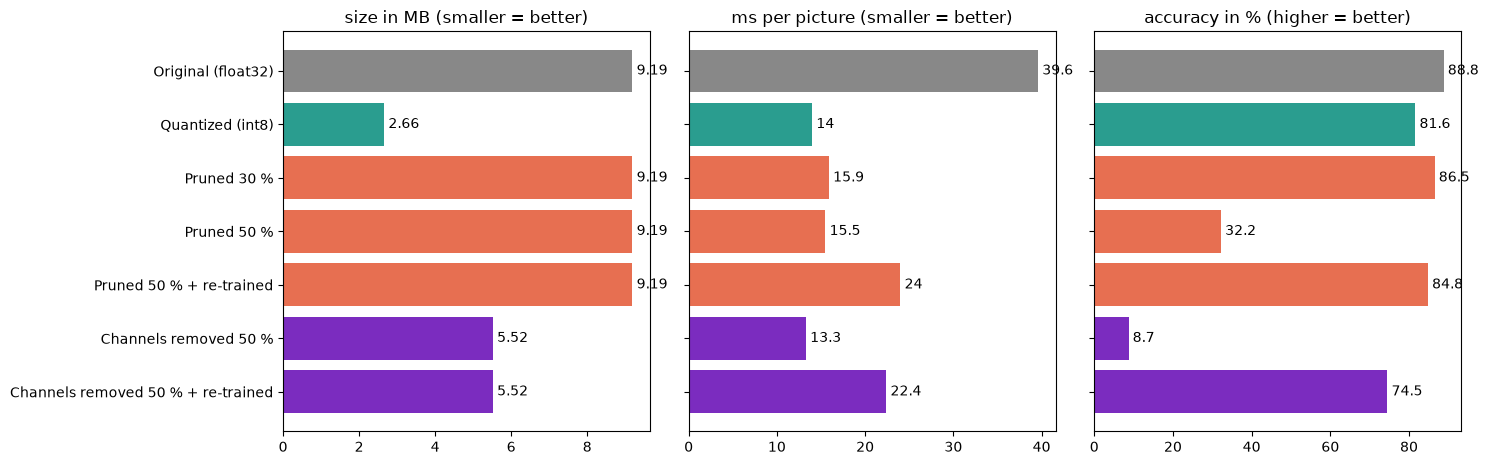

In [14]:
compare(results)

👀 The purple **size** bars are finally shorter, unlike the orange ones. For speed, trust the 32-picture test in Step 6
(times for 1 picture are tiny and jump around with whatever else the computer is doing).

## 🎓 What to remember

1. **Quantization** = rounding every number to 1 byte → **~3.5× smaller**, almost the same accuracy.
   This is what we use in production (Notebook 03 does it for the web app).
2. **Calibration** = showing a few *training* pictures so the model learns the typical ranges.
3. **Unstructured pruning** (single weights → 0) makes the numbers zero, but the tables keep their size:
   the file is **not** smaller (only after zipping) and **not** faster.
4. **Structured pruning** (delete whole channels) makes the tables smaller: **smaller and faster** on any computer,
   but accuracy drops more, so **always re-train** afterwards.

**Want more?** The full notebook `02_quantization_and_pruning.ipynb` also covers dynamic quantization,
float16, quantization-aware training and *why* each result happens.